### 0. Importing PyTorch and setting device-agnostic code 

In [1]:
import torch
from torch import nn

In [2]:
# Setup device-agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### 1. Get data

In [4]:
from pathlib import Path

In [5]:
data_dir = Path("chest_xray")

In [6]:
train_dir = data_dir / "train"
test_dir = data_dir / "test"
val_dir = data_dir / "val"

print(train_dir)
print(test_dir)
print(val_dir)

chest_xray\train
chest_xray\test
chest_xray\val


### 1.1 Visualizing an image

1. Get all of the image paths
2. Pick a random image using Python's random.choice()
3. Get image class using pathlib.Path.parent.stem
4. Since, I am working with images, let's open the image with Python's PIL
5. I'll then show the image and print metadata

In [7]:
import random
from PIL import Image

Image class: NORMAL
Image height: 1804
Image width: 2048


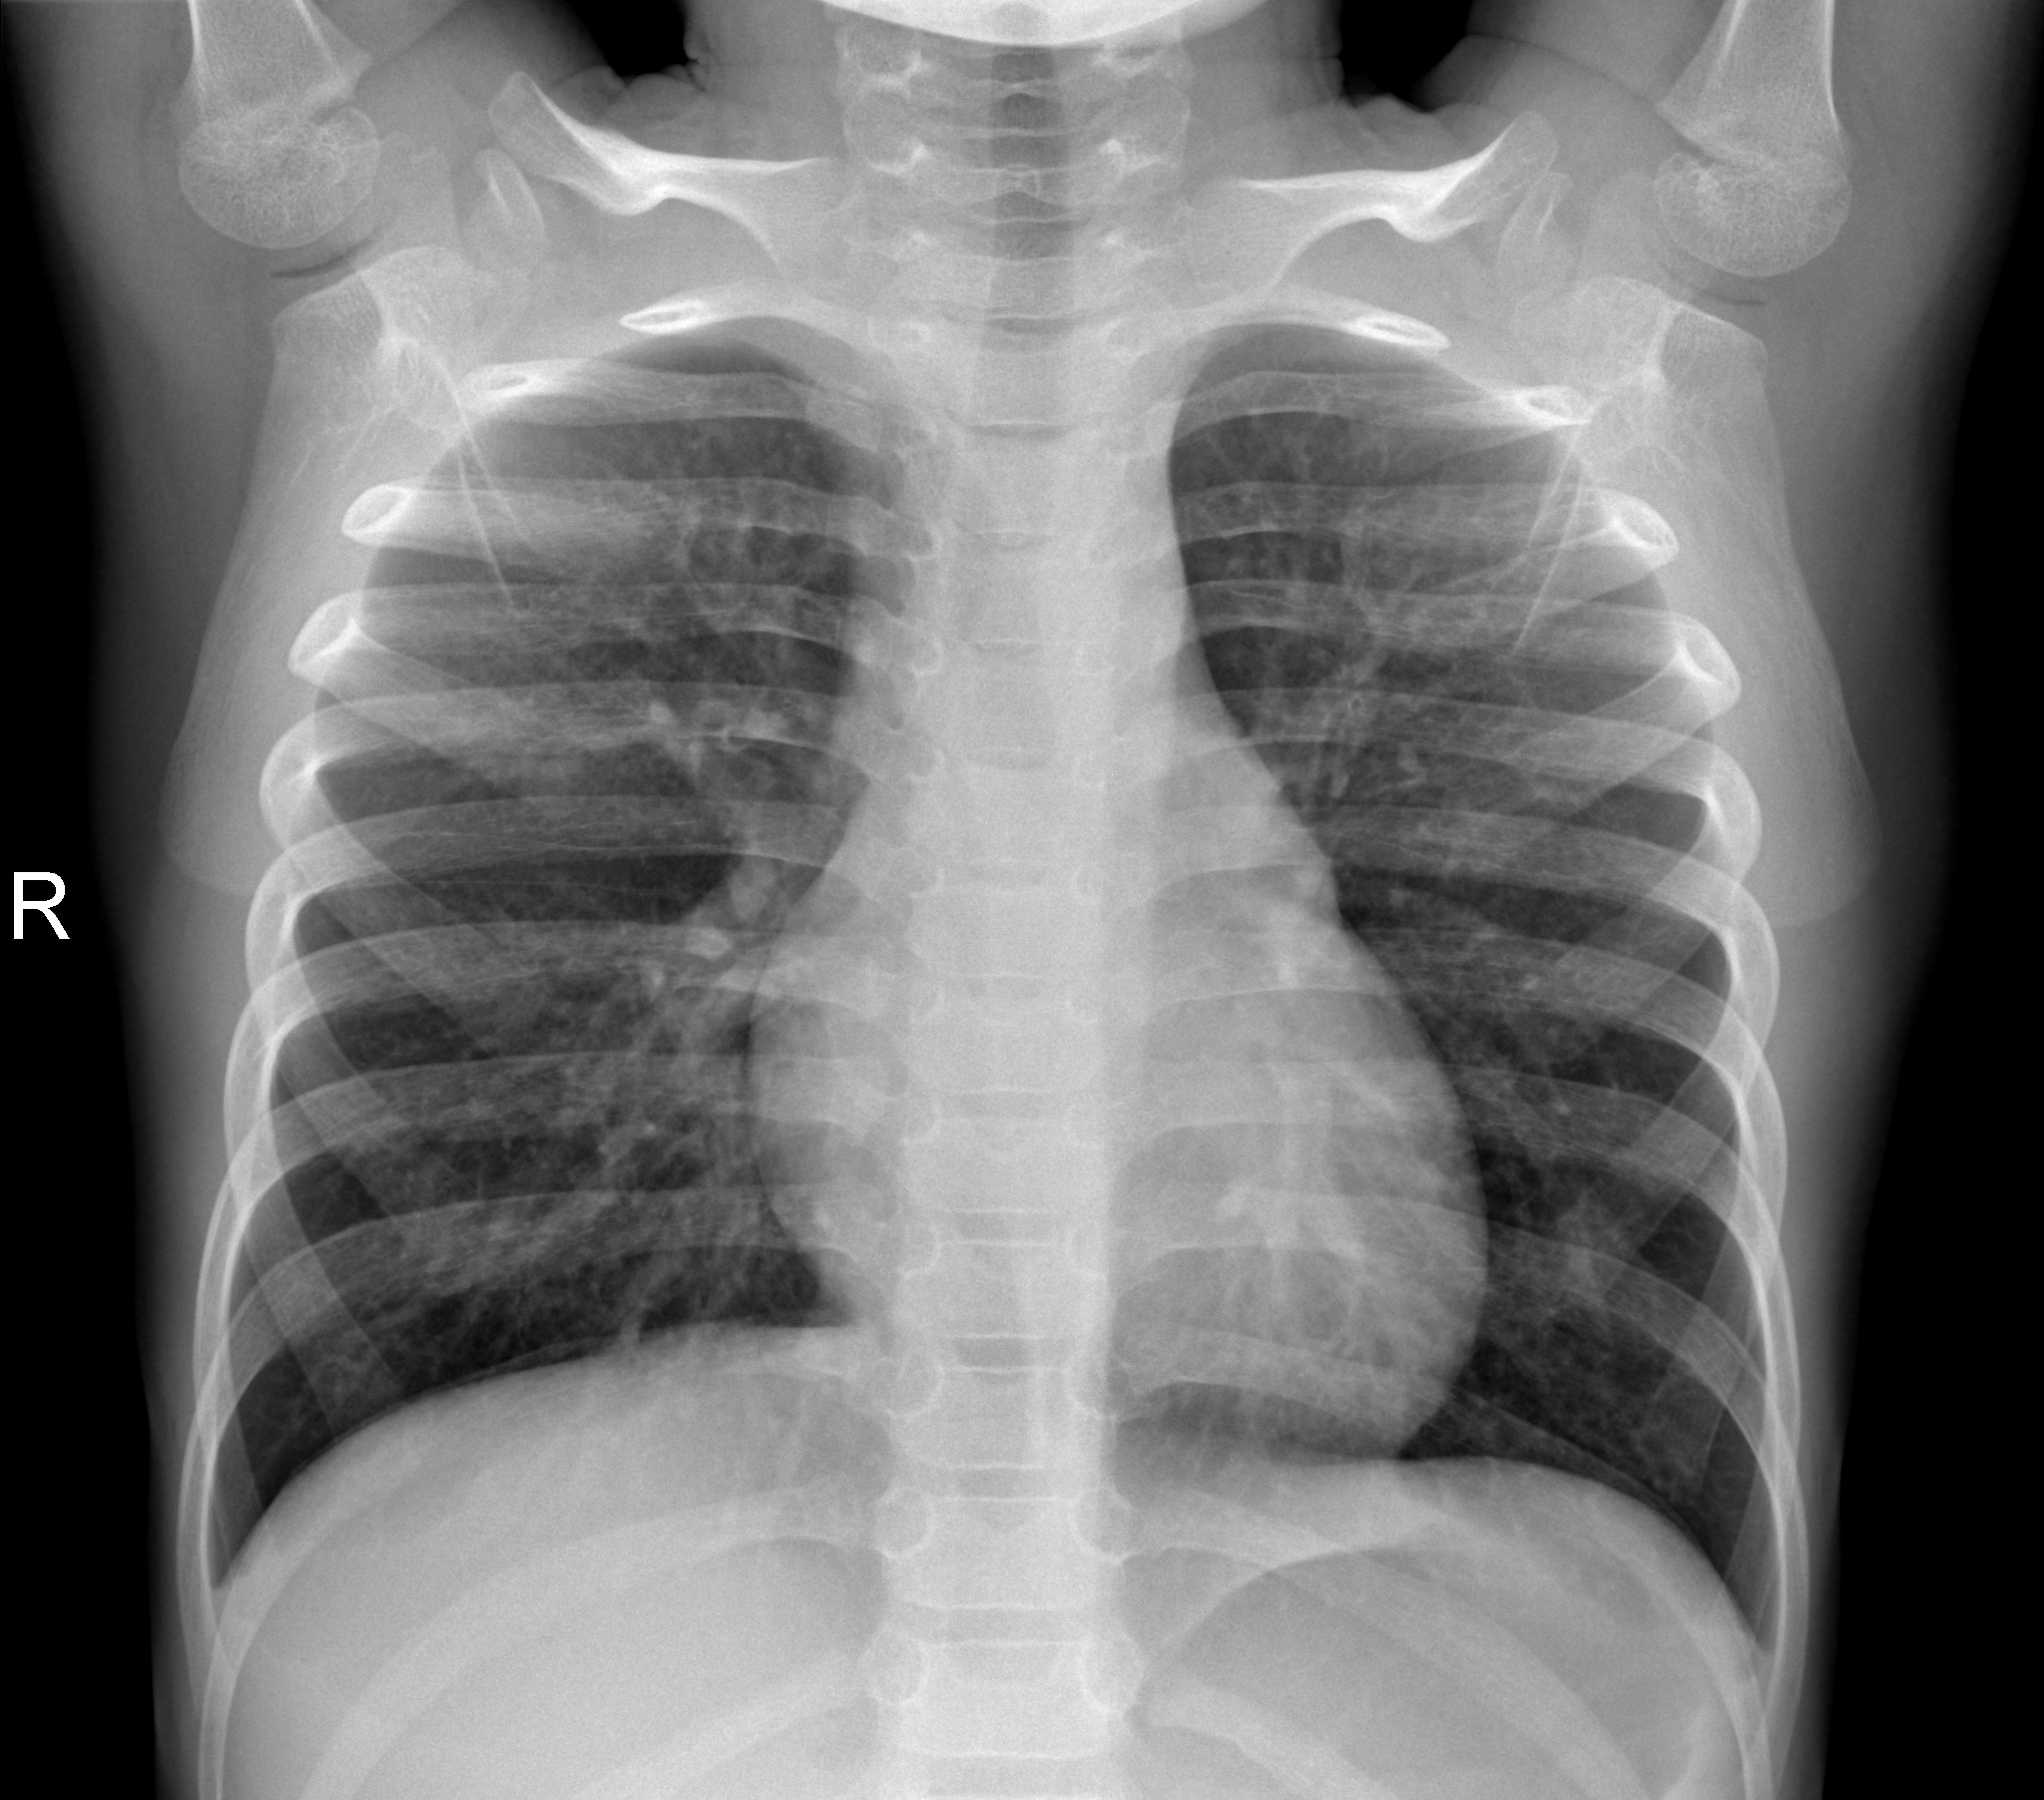

In [12]:
# 1. Getting all the image path 
image_path_list = list(data_dir.glob("*/*/*.jpeg"))
image_path_list

# 2. Pick a random image
random_image_path = random.choice(image_path_list)

# 3. Get the image class from path name(the image class is the name of the directory where the the image is saved)
image_class = random_image_path.parent.stem

# 4. Open the image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

### 2. Making data ready

#### 2.1 Cheking the train and validation split

In [13]:
for split in [train_dir, test_dir, val_dir]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = split / cls
        n = len(list(folder.glob("*.jpeg")))
        print(split.name, cls, n)

train NORMAL 1341
train PNEUMONIA 3875
test NORMAL 234
test PNEUMONIA 390
val NORMAL 8
val PNEUMONIA 8


#### 2.2 Creating new train and validation split (85% and 15%)

In [ ]:
import shutil
import random

random.seed(42)

new_val_dir = Path("chest_xray/new_val")
new_train_dir = Path("chest_xray/new_train")

val_fraction = 0.15 # train and validation split is 85 - 15

for cls in ["NORMAL", "PNEUMONIA"]:
    src_folder = train_dir / cls
    images = list(src_folder.glob("*.jpeg"))
    random.shuffle(images)

    n_val = int(len(images) * val_fraction)
    val_images = images[:n_val]
    train_images = images[n_val:]

    (new_val_dir / cls).mkdir(parents=True, exist_ok=True)
    (new_train_dir / cls).mkdir(parents=True, exist_ok=True)

    for img in val_images:
        shutil.copy(img, new_val_dir / cls / img.name)
    for img in train_images:
        shutil.copy(img, new_train_dir / cls / img.name)

    print(cls, "train:", len(train_images), "val:", len(val_images))

NORMAL train: 1140 val: 201
PNEUMONIA train: 3294 val: 581


### 3. Transforming data

Before I can use our image data with PyTorch:

    1. I need to turn my data into tensors.
    2. Turn into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`. 

In [18]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#### 3.1 Transforming data with `torchvision.transfor`

In [20]:
# transform for images
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size = (64,64)),
    transforms.ToTensor()
])